<div style="font-family: Arial, sans-serif; background-color: #f8f9fa; padding: 20px; border-radius: 10px; box-shadow: 0 4px 6px rgba(0, 0, 0, 0.1);">
  <div style="display: flex; justify-content: space-between; align-items: center;">
    <img src="https://sigmoidal.ai/wp-content/uploads/2024/09/Academia-Sigmoidal-Light.png" alt="Academia Sigmoidal Logo" width="250" height="auto">
    <div style="text-align: right;">
<h1 style="color: #007bff; margin: 0; font-size: 24px;">Bootcamp de Visão Computacional Aplicada a Drones</h1>
    </div>
</div>
<hr style="border: none; height: 1px; background-color: #007bff; margin: 20px 0;">
<h3 style="color: #343a40; margin: 0; font-size: 20px;"><strong>Projeto 3 · Rastreamento de objetos com ByteTrack</strong></h3>
<p style="color: #6c757d; margin: 5px 0 0; font-size: 14px;"><strong>Instrutor:</strong> Carlos Melo, MSc.</p>
</div>

# Rastreamento de objetos com ByteTrack

O objetivo é associar detecções de veículos ao longo do tempo e visualizar identidades e trajetórias. Implementaremos o fluxo **quadro → detector → associação temporal → anotação**, sem acrescentar regras de contagem.

[![Abrir o Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/#create=true)

No Colab, use **Arquivo → Fazer upload de notebook** e selecione este arquivo. Cada notebook é independente e baixa seus próprios dados de uma fonte pública. Execute as células em ordem, desde o início, em uma sessão nova. GPU é recomendada para vídeo; CPU também é selecionada automaticamente quando CUDA não está disponível.

## Preparar o ambiente

O ambiente de referência usa **Python 3.12**. As versões abaixo fixam a API usada nesta aula. A instalação deve ocorrer antes de importar as bibliotecas. Caso o Colab solicite reinicialização, reinicie a sessão e execute novamente desde o início; não misture objetos importados de versões diferentes.

In [1]:
%pip install -q torch==2.8.0 torchvision==0.23.0 \
    supervision==0.30.5 trackers==2.6.1 rfdetr==1.11.0 \
    ultralytics==8.4.163 numpy==2.3.5 transformers==5.17.0 \
    opencv-python==5.0.0.93 imageio-ffmpeg==0.6.0 \
    matplotlib==3.10.7 pandas==2.3.3

Note: you may need to restart the kernel to use updated packages.


## Importar as ferramentas

**RF-DETR** estima caixas, classes e pontuações. **Supervision**, abreviado como `sv`, organiza os resultados, manipula sua geometria e produz visualizações. Os arrays lidos com OpenCV usam a ordem de canais **BGR**; a entrada NumPy do RF-DETR usa **RGB**.

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import supervision as sv
import torch
from pathlib import Path
from urllib.request import urlretrieve
from importlib.metadata import version
from rfdetr import RFDETRMedium
plt.rcParams.update({"font.family": "sans-serif", "font.size": 12,
                     "figure.figsize": (12, 7), "axes.grid": False})
np.set_printoptions(precision=2, suppress=True)

Registramos as versões efetivamente carregadas. Esse registro permite comparar uma execução posterior com o ambiente da aula.

In [3]:
for pacote in ["supervision", "trackers", "rfdetr", "torch", "numpy"]:
    print(pacote, version(pacote))
dispositivo = "cuda" if torch.cuda.is_available() else "cpu"
print("Dispositivo:", dispositivo)

supervision 0.30.5
trackers 2.6.1
rfdetr 1.11.0
torch 2.8.0+cu128
numpy 2.3.5
Dispositivo: cuda


## Obter um vídeo de referência

Usaremos o vídeo público de veículos do cookbook oficial do Supervision, na versão de 1280 × 720 pixels. O arquivo é pequeno e dispensa conta, chave de API e acesso a qualquer repositório da turma. A verificação SHA-256 confirma que o conteúdo baixado corresponde ao material desta aula.

In [4]:
DADOS = Path("dados")
SAIDAS = Path("resultados/02_tracking")
DADOS.mkdir(exist_ok=True)
SAIDAS.mkdir(parents=True, exist_ok=True)
VIDEO = DADOS / "vehicles-1280x720.mp4"
URL = "https://storage.googleapis.com/com-roboflow-marketing/supervision/cookbooks/vehicles-1280x720.mp4"
if not VIDEO.exists():
    urlretrieve(URL, VIDEO)
print("Arquivo:", VIDEO.name)

Arquivo: vehicles-1280x720.mp4


In [5]:
import hashlib
sha256 = hashlib.sha256(VIDEO.read_bytes()).hexdigest()
assert sha256 == "9202baceb8b07949a06a9df821fb11ec536d35cef41eff75beb20701ff2d7f22", "Vídeo diferente da referência."
info = sv.VideoInfo.from_video_path(str(VIDEO))
print(info)
print("Duração (s):", round(info.total_frames / info.fps, 2))

VideoInfo(width=1280, height=720, fps=25.0, total_frames=538)
Duração (s): 21.52


## Detecção e identidade respondem a perguntas diferentes

O detector estima, em cada instante $t$, um conjunto de caixas $\mathbf{b}_t^{(i)}$, categorias $c_t^{(i)}$ e pontuações $s_t^{(i)}$. A posição da previsão na lista pode variar entre quadros; ela não identifica o veículo.

O **rastreamento por detecção** acrescenta uma hipótese de correspondência temporal. Um `tracker_id` associa observações que o algoritmo considera pertencentes à mesma instância. Esse identificador é local à execução e pode fragmentar ou mudar quando a associação falha.

Dois veículos da mesma classe continuam sendo duas instâncias. Somar detecções entre quadros contaria repetidamente as observações dos mesmos veículos.

## Delimitar um experimento curto

Processaremos oito segundos consecutivos, preservando todos os quadros e o FPS de origem. Essa duração permite verificar o resultado rapidamente. Em CPU, reduza `DURACAO_S` para `2.0` se necessário; a lógica permanece a mesma.

Pular quadros altera o deslocamento entre observações e a escala temporal do tracker. Nesta introdução, usamos `stride=1` e informamos a taxa real de quadros.

Quadros a processar: 200


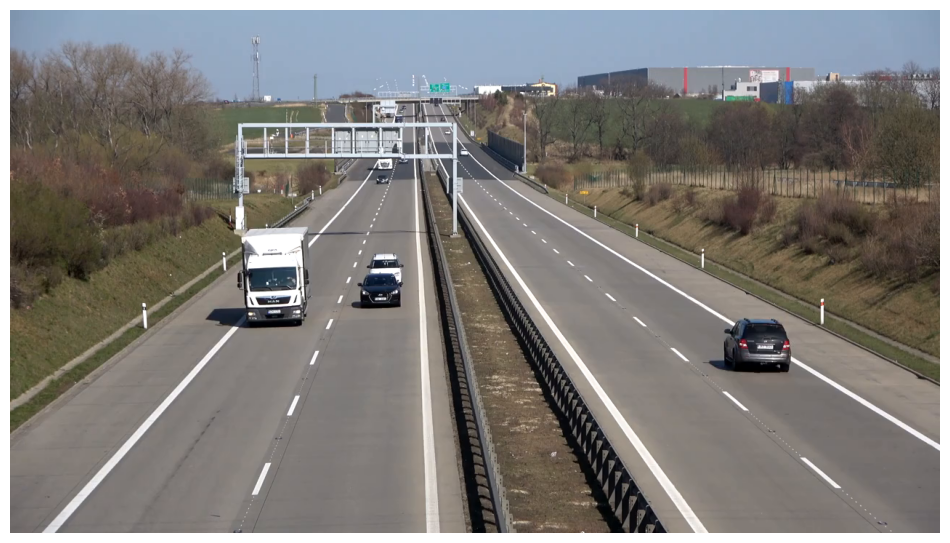

In [6]:
DURACAO_S = 8.0
N_QUADROS = min(info.total_frames, round(DURACAO_S * info.fps))
gerador = sv.get_video_frames_generator(str(VIDEO), end=1)
primeiro_quadro = next(gerador)
gerador.close()
print("Quadros a processar:", N_QUADROS)
sv.plot_image(primeiro_quadro)

## Carregar o detector

Usaremos o RF-DETR Medium com pesos pré-treinados, sem fine-tuning. `inference(compile=False)` prepara o modelo para inferência sem exigir compilação. A conversão explícita BGR → RGB mantém a interpretação correta das cores.

In [7]:
modelo = RFDETRMedium(device=dispositivo)
modelo.inference(compile=False)
classes_veiculos = ["car", "truck", "bus", "motorcycle"]
LIMIAR_DETECTOR = 0.10

[2026-09-26 02:22:09] [INFO] rf-detr - File /root/.roboflow/models/rf-detr-medium.pth already exists with correct MD5 hash.


[2026-09-26 02:22:09] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-09-26 02:22:09] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-09-26 02:22:10] [INFO] rf-detr - File /root/.roboflow/models/rf-detr-medium.pth already exists with correct MD5 hash.


O limiar do detector é deliberadamente inferior ao limiar que separa as etapas de associação do ByteTrack. Se descartássemos antecipadamente as detecções de menor confiança, o rastreador perderia a oportunidade de utilizá-las para recuperar trajetórias existentes.

In [8]:
def detectar(quadro):
    rgb = cv2.cvtColor(quadro, cv2.COLOR_BGR2RGB)
    deteccoes = modelo.predict(rgb, threshold=LIMIAR_DETECTOR,
                               include_source_image=False)
    selecionadas = np.isin(deteccoes["class_name"], classes_veiculos)
    return deteccoes[selecionadas]

Antes de acrescentar memória temporal, inspecionamos a saída do detector em um quadro. Essa verificação ajuda a distinguir problemas de detecção de problemas de associação.

Veículos detectados: 37
Confianças: [0.93 0.93 0.53 0.52 0.49 0.4  0.39 0.39 0.35 0.33 0.32 0.29 0.27 0.24
 0.2  0.2  0.19 0.18 0.16 0.16 0.16 0.15 0.14 0.12 0.12 0.12 0.12 0.12
 0.12 0.11 0.11 0.11 0.11 0.11 0.1  0.1  0.1 ]


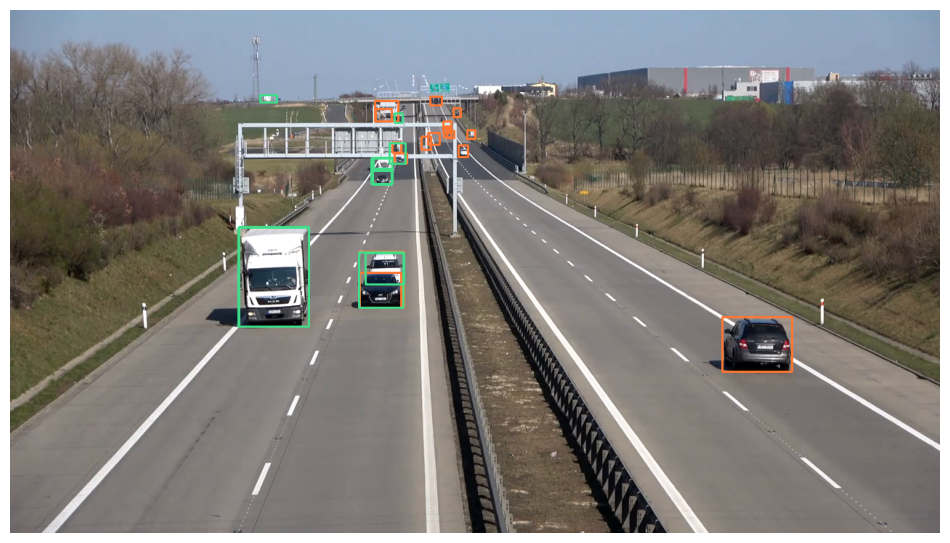

In [9]:
deteccoes_iniciais = detectar(primeiro_quadro)
print("Veículos detectados:", len(deteccoes_iniciais))
print("Confianças:", deteccoes_iniciais.confidence)
previa = sv.BoxAnnotator(thickness=2).annotate(
    primeiro_quadro.copy(), deteccoes_iniciais)
sv.plot_image(previa)

## Como ByteTrack associa observações

O algoritmo mantém um estado de movimento para cada trajetória e prevê sua próxima caixa. Uma medida de sobreposição, a **Intersection over Union**, ajuda a comparar caixas previstas e observadas:

$$\operatorname{IoU}(A,B)=\frac{|A\cap B|}{|A\cup B|}.$$

ByteTrack faz a associação em duas etapas: primeiro considera detecções de maior confiança; depois tenta recuperar trajetórias ainda sem correspondência usando detecções de menor confiança. Novas trajetórias só começam a partir de detecções elegíveis da primeira etapa.

Esta implementação usa geometria e estado de movimento. **Não calcula descritores de aparência, não executa reidentificação e não compensa o movimento da câmera.** Atribuir um ID não equivale a reconhecer permanentemente o mesmo veículo.

### Parâmetros da experiência

| Parâmetro | Valor | Papel |
|:--|:--|:--|
| `LIMIAR_DETECTOR` | 0.10 | Menor score enviado ao tracker |
| `high_conf_det_threshold` | 0.25 | Separa a primeira da segunda etapa |
| `track_activation_threshold` | 0.35 | Score mínimo para iniciar uma trajetória |
| `minimum_consecutive_frames` | 2 | Evidência consecutiva para confirmar um ID |
| `minimum_iou_threshold` | 0.10 | Sobreposição mínima para aceitar associação |
| `lost_track_buffer` | 30 | Tolerância a ausência, em unidades de 30 FPS |

São escolhas didáticas para este vídeo, não parâmetros universais nem um ajuste validado em benchmark. Com `frame_rate=info.fps`, o buffer de 30 corresponde aproximadamente a um segundo de ausência.

In [10]:
from trackers import ByteTrackTracker
def criar_rastreador():
    return ByteTrackTracker(frame_rate=info.fps,
        high_conf_det_threshold=0.25, track_activation_threshold=0.35,
        minimum_consecutive_frames=2, minimum_iou_threshold=0.10,
        lost_track_buffer=30)

## Desenhar identidades e trajetórias

`ColorLookup.TRACK` associa cores aos IDs. O rastro desenha posições recentes do centro da caixa; é uma trajetória na imagem, medida em pixels, e não uma trajetória métrica no solo.

A paleta tem um número finito de cores e pode reutilizá-las. O rótulo numérico continua necessário para distinguir identidades.

In [11]:
paleta = sv.ColorPalette.from_hex(["#00D4AA", "#4DA3FF", "#FFCC66", "#FF6B8A"])
caixas = sv.BoxAnnotator(color=paleta, thickness=2,
    color_lookup=sv.ColorLookup.TRACK)
rotulos = sv.LabelAnnotator(color=paleta, text_scale=0.45,
    text_thickness=1, text_padding=3, color_lookup=sv.ColorLookup.TRACK)

Separaremos o desenho da associação. A função abaixo recebe apenas detecções já associadas, compõe três anotadores e devolve um novo quadro.

In [12]:
def anotar(quadro, associadas, rastros):
    if len(associadas) == 0:
        return quadro.copy()
    etiquetas = [f"#{identidade} {classe}" for identidade, classe
                 in zip(associadas.tracker_id, associadas["class_name"])]
    imagem = rastros.annotate(quadro.copy(), associadas)
    imagem = caixas.annotate(imagem, associadas)
    return rotulos.annotate(imagem, associadas, etiquetas)

## Registrar o processo

Guardaremos uma linha por quadro com o número de detecções, IDs confirmados visíveis e detecções sem ID confirmado. Essa tabela descreve o funcionamento da experiência; não calcula quantidade de veículos únicos nem qualidade de rastreamento.

In [13]:
def processar(quadro, indice, rastreador, rastros, registros):
    deteccoes = detectar(quadro)
    retorno = rastreador.update(deteccoes)
    confirmadas = retorno[retorno.tracker_id != -1]
    registros.append({"quadro": indice, "tempo_s": indice / info.fps,
        "deteccoes": len(deteccoes), "ids_visiveis": len(confirmadas),
        "sem_id": int(np.sum(retorno.tracker_id == -1))})
    return anotar(quadro, confirmadas, rastros)

O valor `-1` indica ausência de ID confirmado, não uma identidade compartilhada entre objetos. **O ID zero é válido** e deve ser preservado. Essas detecções participaram da atualização, mas serão omitidas do desenho dos rastros. O estado do tracker ainda deve ser atualizado quando não há detecções. Ele pode preservar uma trajetória durante uma ausência, mas nosso desenho mostra somente caixas observadas e associadas no quadro atual; não desenha caixas previstas sem observação.

## Executar a sequência completa

O rastreador e o histórico de rastros são recriados na mesma célula que processa o vídeo. Assim, executar novamente o experimento começa do quadro zero com estado limpo.

`VideoSink` grava os quadros anotados na resolução e taxa da origem. As funções definidas acima mantêm cada etapa explícita: detectar, associar, registrar e desenhar.

In [14]:
from time import perf_counter
VIDEO_ANOTADO = SAIDAS / "tracking.mp4"
registros = []
rastreador = criar_rastreador()
rastros = sv.TraceAnnotator(color=paleta, thickness=2,
    trace_length=round(info.fps * 2), color_lookup=sv.ColorLookup.TRACK)
inicio = perf_counter()
gerador = sv.get_video_frames_generator(str(VIDEO), end=N_QUADROS)
with sv.VideoSink(str(VIDEO_ANOTADO), video_info=info) as destino:
    for indice, quadro in enumerate(gerador):
        destino.write_frame(processar(quadro, indice, rastreador, rastros, registros))
segundos = perf_counter() - inicio

## Conferir a execução e inspecionar o resultado

O número de quadros gravados deve coincidir com o número processado. O tempo medido inclui inferência, associação, desenho e escrita do vídeo; não é a latência isolada do detector nem uma promessa de desempenho em outros equipamentos.

In [15]:
import pandas as pd
from IPython.display import display
tabela = pd.DataFrame(registros)
tabela.to_csv(SAIDAS / "observacoes_por_quadro.csv", index=False)
saida_info = sv.VideoInfo.from_video_path(str(VIDEO_ANOTADO))
assert len(tabela) == N_QUADROS == saida_info.total_frames
assert (tabela["ids_visiveis"] > 0).any(), "Nenhum ID confirmado."
print("Tempo de processamento (s):", round(segundos, 2))
print("Quadros processados por segundo:", round(len(tabela) / segundos, 2))
display(tabela.head())

Tempo de processamento (s): 4.2
Quadros processados por segundo: 47.63


,quadro,tempo_s,deteccoes,ids_visiveis,sem_id
0,0,0.00,37,0,37
1,1,0.04,48,9,39
2,2,0.08,41,11,30
3,3,0.12,44,11,33
4,4,0.16,39,11,28


A leitura de três quadros permite conferir resolução, rótulos e trajetórias sem depender do player. O quadro inicial pode ainda não conter IDs confirmados, pois exigimos observações consecutivas.

Quadro 0


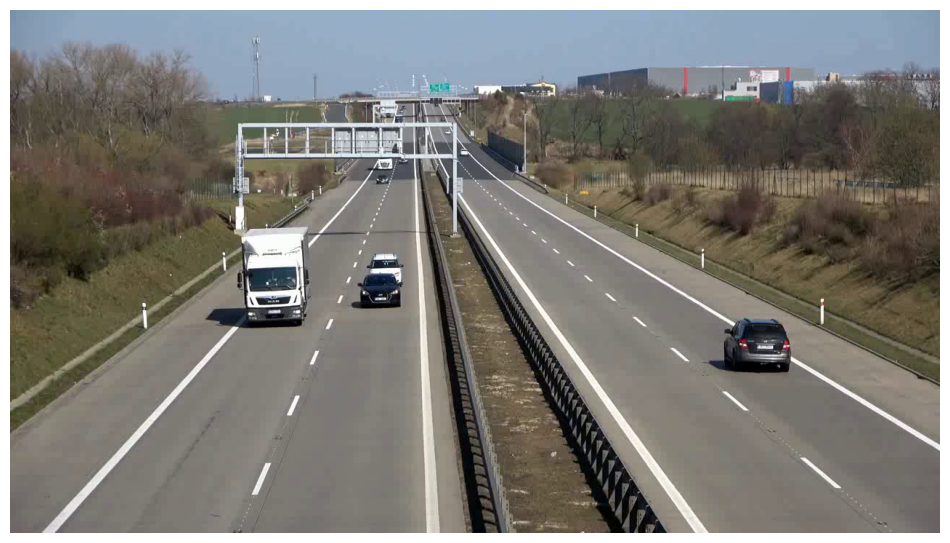

Quadro 100


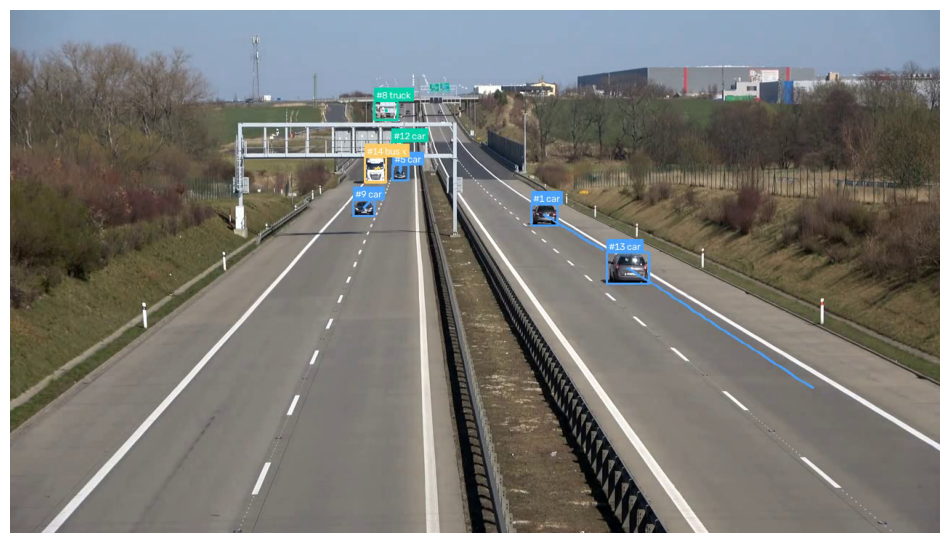

Quadro 199


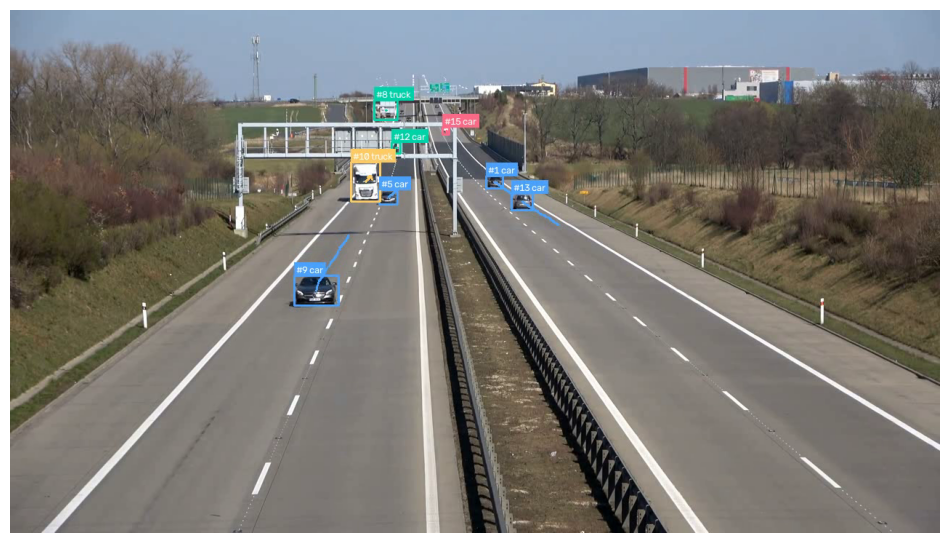

In [16]:
for indice in [0, N_QUADROS // 2, N_QUADROS - 1]:
    leitura = sv.get_video_frames_generator(str(VIDEO_ANOTADO), start=indice)
    amostra = next(leitura)
    leitura.close()
    cv2.imwrite(str(SAIDAS / f"quadro_{indice:04d}.jpg"), amostra)
    print("Quadro", indice)
    sv.plot_image(amostra)

### Reproduzir no navegador

O contêiner MP4, por si só, não garante compatibilidade com o navegador. Geraremos uma cópia H.264 para visualização, mantendo a saída original. Essa conversão não altera as detecções nem executa o tracker novamente.

In [17]:
import subprocess
import imageio_ffmpeg
from IPython.display import Video, display
VIDEO_WEB = SAIDAS / "tracking_h264.mp4"
comando = [imageio_ffmpeg.get_ffmpeg_exe(), "-y", "-i", str(VIDEO_ANOTADO),
    "-c:v", "libx264", "-crf", "20", "-pix_fmt", "yuv420p",
    "-movflags", "+faststart", str(VIDEO_WEB)]
subprocess.run(comando, check=True, capture_output=True)
display(Video(str(VIDEO_WEB), embed=True, width=960))

## Interpretar falhas de associação

Observe um veículo por vez. Verifique se o ID se mantém durante aproximação, oclusão parcial e separação de outros veículos. Um rastro visualmente suave pode estar associado ao objeto errado; continuidade gráfica não comprova identidade correta.

**Fragmentação** ocorre quando uma mesma trajetória física recebe mais de um ID. Uma **troca de identidade** ocorre quando um ID passa a acompanhar outro objeto. Detecções ausentes, caixas instáveis, objetos muito pequenos e movimento da câmera dificultam a associação.

Sem anotações temporais de referência, este vídeo é uma inspeção qualitativa. Não permite relatar HOTA, IDF1 ou MOTA, nem concluir que o rastreador identifica corretamente todos os veículos.

## Experimentos orientados

- Aumente `LIMIAR_DETECTOR` para `0.50` e execute novamente. Quais observações deixam de chegar à segunda etapa do tracker?
- Aumente `minimum_consecutive_frames` para `3`. Compare o atraso até aparecer um ID e a quantidade de trajetórias muito curtas.
- Reduza o buffer e observe o efeito em ausências temporárias. Um buffer maior também pode aumentar o risco de reassociar objetos diferentes.
- Escolha um intervalo curto, acompanhe manualmente dois veículos e registre qualquer troca ou fragmentação de ID.

No projeto final, a mesma estrutura receberá regras espaciais e um protocolo de conferência dos eventos. A contagem dependerá da qualidade da detecção, da continuidade dos IDs e da definição geométrica do evento.

## Referências

- [ByteTrack: artigo original](https://arxiv.org/abs/2110.06864)
- [ByteTrackTracker: documentação](https://trackers.roboflow.com/latest/trackers/bytetrack/)
- [Migração de `sv.ByteTrack` para `trackers`](https://supervision.roboflow.com/latest/trackers/)
- [Cookbook oficial usado como referência](https://github.com/roboflow/supervision/blob/f132aa01da7d42b36f8615f923285e1839b5e05e/docs/notebooks/count-objects-crossing-the-line.ipynb)
- [RF-DETR: inferência](https://rfdetr.roboflow.com/latest/learn/run/detection/)

Consulta das fontes: 26/09/2026. Esta aula isola a associação temporal e não inclui o contador do cookbook.